In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
pip install transformers torchvision pandas scikit-learn


  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer
from torchvision import transforms
from PIL import Image
import os

# Load the CSV file
csv_path = '/content/drive/MyDrive/Research/Dataset Collection/Dataset_text.csv'
df = pd.read_csv(csv_path)

# Verify column names
print(df.columns)

# Drop unnecessary columns if they exist
columns_to_drop = [col for col in ['Source', 'Domain', 'Unnamed: 5'] if col in df.columns]
df = df.drop(columns_to_drop, axis=1)

# Shuffle the dataframe
df = shuffle(df, random_state=42)

# Split the dataset
train_ratio = 0.6
val_ratio = 0.2
test_ratio = 0.2

train_data, val_test = train_test_split(df, train_size=train_ratio, random_state=42)
valid_data, test_data = train_test_split(val_test, train_size=val_ratio / (val_ratio + test_ratio), random_state=42)

# Define the transformations for the images
image_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the tokenizer
tokenizer = BertTokenizer.from_pretrained('sagorsarker/bangla-bert-base')

# Custom Dataset class
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, images_folder, tokenizer, image_transforms):
        self.dataframe = dataframe
        self.images_folder = images_folder
        self.tokenizer = tokenizer
        self.image_transforms = image_transforms

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        text = row['Caption']
        label = row['Label']
        image_id = row['Image id']

        # Check for both .jpg and .png extensions
        image_path_jpg = os.path.join(self.images_folder, f"{image_id}.jpg")
        image_path_png = os.path.join(self.images_folder, f"{image_id}.png")

        # Debugging output
        #print(f"Checking image paths: {image_path_jpg} and {image_path_png}")

        if os.path.exists(image_path_jpg):
            image_path = image_path_jpg
        elif os.path.exists(image_path_png):
            image_path = image_path_png
        else:
            # List the directory contents for further debugging
            print(f"Directory contents: {os.listdir(self.images_folder)}")
            raise FileNotFoundError(f"Image {image_id} not found with .jpg or .png extension")

        image = Image.open(image_path).convert('RGB')
        image = self.image_transforms(image)

        text_inputs = self.tokenizer(text, return_tensors='pt', padding='max_length', truncation=True, max_length=128)

        return {
            'input_ids': text_inputs['input_ids'].squeeze(),
            'attention_mask': text_inputs['attention_mask'].squeeze(),
            'image': image,
            'label': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
images_folder = '/content/drive/MyDrive/Research/Dataset Collection/unzipped/Without text/'
train_dataset = MultimodalDataset(train_data, images_folder, tokenizer, image_transforms)
valid_dataset = MultimodalDataset(valid_data, images_folder, tokenizer, image_transforms)
test_dataset = MultimodalDataset(test_data, images_folder, tokenizer, image_transforms)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


Index(['Image id', 'Caption', 'Label', 'Source', 'Domain', 'Unnamed: 5'], dtype='object')


vocab.txt:   0%|          | 0.00/2.24M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

In [78]:
print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

3003
1001
1002


In [79]:
import torch.nn as nn
from transformers import BertModel
import torchvision.models as models

class MultimodalModel(nn.Module):
    def __init__(self, text_model_name='sagorsarker/bangla-bert-base', num_labels=2):
        super(MultimodalModel, self).__init__()
        self.text_model = BertModel.from_pretrained(text_model_name)
        self.image_model = models.resnet50(pretrained=True)
        self.image_model.fc = nn.Linear(self.image_model.fc.in_features, 768)  # Adjust to match BERT output size

        self.classifier = nn.Linear(768 * 2, num_labels)

    def forward(self, input_ids, attention_mask, image):
        text_outputs = self.text_model(input_ids=input_ids, attention_mask=attention_mask)
        text_embeds = text_outputs.last_hidden_state[:, 0, :]  # Use [CLS] token embedding

        image_embeds = self.image_model(image)

        combined_embeds = torch.cat((text_embeds, image_embeds), dim=1)
        logits = self.classifier(combined_embeds)

        return logits

model = MultimodalModel(num_labels=len(df['Label'].unique()))


model.safetensors:   0%|          | 0.00/660M [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [80]:
import torch.optim as optim
from torch.nn import CrossEntropyLoss
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-5)
criterion = CrossEntropyLoss()

def train_model(model, train_loader, valid_loader, epochs=5):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}, Train Loss: {avg_train_loss}")

        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for batch in valid_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                images = batch['image'].to(device)
                labels = batch['label'].to(device)

                outputs = model(input_ids, attention_mask, images)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(valid_loader)
        print(f"Epoch {epoch + 1}, Validation Loss: {avg_val_loss}")

train_model(model, train_loader, valid_loader, epochs=5)


100%|██████████| 94/94 [03:00<00:00,  1.92s/it]


Epoch 1, Train Loss: 0.43442174205754663
Epoch 1, Validation Loss: 0.3004786898382008


100%|██████████| 94/94 [02:59<00:00,  1.91s/it]


Epoch 2, Train Loss: 0.19183402516423387
Epoch 2, Validation Loss: 0.22868796344846487


100%|██████████| 94/94 [02:58<00:00,  1.90s/it]


Epoch 3, Train Loss: 0.08658023238023545
Epoch 3, Validation Loss: 0.22133481956552714


100%|██████████| 94/94 [03:00<00:00,  1.91s/it]


Epoch 4, Train Loss: 0.04041545447754733
Epoch 4, Validation Loss: 0.24405457713874057


100%|██████████| 94/94 [02:58<00:00,  1.90s/it]


Epoch 5, Train Loss: 0.017951581381915258
Epoch 5, Validation Loss: 0.2720424094295595


In [81]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [82]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, images)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_labels = ['Commercial' if label == 1 else 'Non commercial' for label in all_labels]
    all_preds = ['Commercial' if pred == 1 else 'Non commercial' for pred in all_preds]
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    report = classification_report(all_labels, all_preds)

    return accuracy, precision, recall, f1, report, all_labels, all_preds


In [83]:
def plot_confusion_matrix(all_labels, all_preds):
    labels = ['Commercial', 'Non commercial']
    cm = confusion_matrix(all_labels, all_preds, labels=labels)
    plt.figure(figsize=(8, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


In [84]:
test_accuracy, test_precision, test_recall, test_f1, test_report, all_labels, all_preds = evaluate_model(model, test_loader)

print(f"Test Accuracy: {test_accuracy}")
print(f"Test Precision: {test_precision}")
print(f"Test Recall: {test_recall}")
print(f"Test F1 Score: {test_f1}")
print("Classification Report:\n", test_report)

# Plot the confusion matrix
#plot_confusion_matrix(all_labels, all_preds)

Test Accuracy: 0.9281437125748503
Test Precision: 0.9280865254662445
Test Recall: 0.9281437125748503
Test F1 Score: 0.9280546339271706
Classification Report:
                 precision    recall  f1-score   support

    Commercial       0.93      0.94      0.94       573
Non commercial       0.92      0.91      0.92       429

      accuracy                           0.93      1002
     macro avg       0.93      0.93      0.93      1002
  weighted avg       0.93      0.93      0.93      1002



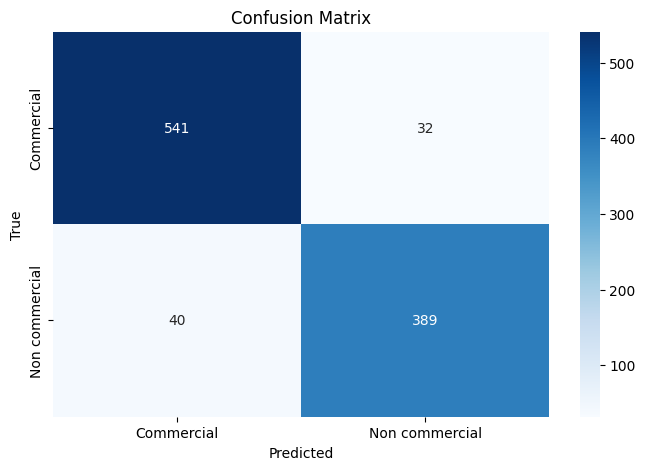

In [85]:
plot_confusion_matrix(all_labels, all_preds)